# 12 — Food Knowledge Base Creation

**Project:** GroundedNutriRec  
**Scope:** Build a structured knowledge base of food/recipe documents that can be ingested by a RAG (Retrieval-Augmented Generation) pipeline.  

## Objectives
1. Load recipe data from `RAW_recipes.csv` and interaction/review data from `RAW_interactions.csv` (archive_3 dataset).
2. Parse the `nutrition` field to extract **calories**, **total fat (% DV)**, and **protein (% DV)**.
3. Aggregate user reviews per recipe — compute **average rating** and a **representative review summary** (most-voted/longest review).
4. Construct one **text document per recipe/food item** containing:
   - Name
   - Ingredients
   - Calories, Protein, Fat
   - Prep time (minutes)
   - Rating
   - Review summary
5. Save the knowledge base as a CSV (`food_knowledge_base.csv`) and as a JSON-Lines file (`food_knowledge_base.jsonl`) for downstream vector-search ingestion.
6. Perform basic quality checks and display sample documents.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import ast
import json
import warnings
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────
RECIPES_PATH  = Path('dataset/archive_3/RAW_recipes.csv')
REVIEWS_PATH  = Path('dataset/archive_3/RAW_interactions.csv')
OUTPUT_DIR    = Path('dataset/archive_3')
KB_CSV_PATH   = OUTPUT_DIR / 'food_knowledge_base.csv'
KB_JSONL_PATH = OUTPUT_DIR / 'food_knowledge_base.jsonl'

print(f'Recipes source : {RECIPES_PATH}')
print(f'Reviews source : {REVIEWS_PATH}')
print(f'Output CSV     : {KB_CSV_PATH}')
print(f'Output JSONL   : {KB_JSONL_PATH}')
print('Setup complete.')

Recipes source : dataset\archive_3\RAW_recipes.csv
Reviews source : dataset\archive_3\RAW_interactions.csv
Output CSV     : dataset\archive_3\food_knowledge_base.csv
Output JSONL   : dataset\archive_3\food_knowledge_base.jsonl
Setup complete.


## 2. Load Datasets

We load both the raw recipes and the raw user interactions (reviews + ratings).

In [2]:
# ── Load recipes ────────────────────────────────────────
print('Loading RAW_recipes.csv...')
recipes_df = pd.read_csv(RECIPES_PATH)
print(f'  Recipes shape : {recipes_df.shape}')
print(f'  Columns       : {recipes_df.columns.tolist()}')

# ── Load interactions ────────────────────────────────────
print('\nLoading RAW_interactions.csv...')
reviews_df = pd.read_csv(REVIEWS_PATH)
print(f'  Interactions shape : {reviews_df.shape}')
print(f'  Columns            : {reviews_df.columns.tolist()}')

print('\n── Recipes preview ──')
recipes_df.head(3)

Loading RAW_recipes.csv...


  Recipes shape : (231637, 12)
  Columns       : ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']

Loading RAW_interactions.csv...


  Interactions shape : (1132367, 5)
  Columns            : ['user_id', 'recipe_id', 'date', 'rating', 'review']

── Recipes preview ──


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


## 3. Parse Nutrition Field

The `nutrition` column is stored as a string list:  
`[calories, total_fat_%DV, sugar_%DV, sodium_%DV, protein_%DV, sat_fat_%DV, carbs_%DV]`

We extract **calories** (index 0), **total fat %DV** (index 1), and **protein %DV** (index 4).

In [3]:
print('Parsing nutrition field (vectorised)...')

nutrition_split = (
    recipes_df['nutrition']
    .str.strip('[]')
    .str.split(',', expand=True)
    .astype(float)
)

recipes_df['calories']      = nutrition_split[0]
recipes_df['total_fat_pdv'] = nutrition_split[1]
recipes_df['protein_pdv']   = nutrition_split[4]

print('Nutrition columns added.')
recipes_df[['name', 'calories', 'total_fat_pdv', 'protein_pdv']].head(5)

Parsing nutrition field (vectorised)...


Nutrition columns added.


,name,calories,total_fat_pdv,protein_pdv
0,arriba baked winter squash mexican style,51.5,0.0,2.0
1,a bit different breakfast pizza,173.4,18.0,22.0
2,all in the kitchen chili,269.8,22.0,39.0
3,alouette potatoes,368.1,17.0,14.0
4,amish tomato ketchup for canning,352.9,1.0,3.0


## 4. Parse Ingredients

The `ingredients` column is a stringified Python list. We convert it into a clean, comma-separated string.

In [4]:
def safe_parse_list(s):
    """Parse a stringified Python list into a real list; return empty list on failure."""
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return []

print('Parsing ingredients...')
recipes_df['ingredients_list'] = recipes_df['ingredients'].apply(safe_parse_list)
recipes_df['ingredients_str']  = recipes_df['ingredients_list'].apply(lambda x: ', '.join(x))

print('Done. Sample:')
recipes_df[['name', 'ingredients_str']].head(3)

Parsing ingredients...


Done. Sample:


,name,ingredients_str
0,arriba baked winter squash mexican style,"winter squash, mexican seasoning, mixed spice,..."
1,a bit different breakfast pizza,"prepared pizza crust, sausage patty, eggs, mil..."
2,all in the kitchen chili,"ground beef, yellow onions, diced tomatoes, to..."


## 5. Aggregate Reviews per Recipe

For each recipe we compute:
- **avg_rating** — mean of all user ratings.
- **review_count** — total number of reviews.
- **review_summary** — the single longest review (as a proxy for the most informative one). If no review is available we use `'No reviews available.'`.

In [5]:
print('Aggregating reviews per recipe...')

# Drop rows where review text is missing
reviews_clean = reviews_df.dropna(subset=['review']).copy()
reviews_clean['review_len'] = reviews_clean['review'].str.len()

# Average rating per recipe
rating_agg = reviews_clean.groupby('recipe_id').agg(
    avg_rating   = ('rating', 'mean'),
    review_count = ('rating', 'count')
).reset_index()

# Pick the longest review per recipe as the 'summary'
idx_longest = reviews_clean.groupby('recipe_id')['review_len'].idxmax()
longest_reviews = reviews_clean.loc[idx_longest, ['recipe_id', 'review']].rename(
    columns={'review': 'review_summary'}
)

# Merge
review_agg = rating_agg.merge(longest_reviews, on='recipe_id', how='left')

print(f'  Unique recipes with reviews: {len(review_agg):,}')
review_agg.head(3)

Aggregating reviews per recipe...


  Unique recipes with reviews: 231,630


,recipe_id,avg_rating,review_count,review_summary
0,38,4.250000,4,Tasty and refreshing! I love the creamy flavor...
1,39,3.000000,1,I have an Indian friend who made this dish for...
2,40,4.333333,9,My favourite lemonade recipe is essentially th...


## 6. Merge Recipes and Reviews

Join the aggregated review data back into the recipes DataFrame.

In [6]:
print('Merging recipes ↔ reviews...')

kb_df = recipes_df.merge(
    review_agg,
    left_on='id',
    right_on='recipe_id',
    how='left'
)

# Fill missing review data
kb_df['avg_rating']      = kb_df['avg_rating'].fillna(0.0).round(2)
kb_df['review_count']    = kb_df['review_count'].fillna(0).astype(int)
kb_df['review_summary']  = kb_df['review_summary'].fillna('No reviews available.')

# Clean prep time
kb_df['prep_time_mins'] = kb_df['minutes'].clip(lower=0)

print(f'Knowledge-base shape: {kb_df.shape}')
kb_df[['name', 'ingredients_str', 'calories', 'protein_pdv',
       'total_fat_pdv', 'prep_time_mins', 'avg_rating', 'review_summary']].head(3)

Merging recipes ↔ reviews...


Knowledge-base shape: (231637, 22)


,name,ingredients_str,calories,protein_pdv,total_fat_pdv,prep_time_mins,avg_rating,review_summary
0,arriba baked winter squash mexican style,"winter squash, mexican seasoning, mixed spice,...",51.5,2.0,0.0,55,5.0,I used an acorn squash and recipe#137681 Swee...
1,a bit different breakfast pizza,"prepared pizza crust, sausage patty, eggs, mil...",173.4,22.0,18.0,30,3.5,No leftovers here. As Coleen114 mentioned this...
2,all in the kitchen chili,"ground beef, yellow onions, diced tomatoes, to...",269.8,39.0,22.0,130,4.0,I added black beans and corn to this and LOVED...


## 7. Construct Knowledge-Base Documents

Each document is a **single structured text string** that will later be embedded by a SentenceTransformer.  
Format:
```
Recipe: <name>
Ingredients: <comma-separated list>
Calories: <value> kcal | Protein: <value> %DV | Fat: <value> %DV
Prep Time: <value> minutes
Average Rating: <value>/5 (<count> reviews)
Review Summary: <text>
```

In [7]:
def build_document(row):
    """Create a single knowledge-base document string from a recipe row."""
    # Truncate very long reviews to 500 chars for embedding efficiency
    review = str(row['review_summary'])[:500]
    doc = (
        f"Recipe: {row['name']}\n"
        f"Ingredients: {row['ingredients_str']}\n"
        f"Calories: {row['calories']:.1f} kcal | "
        f"Protein: {row['protein_pdv']:.1f} %DV | "
        f"Fat: {row['total_fat_pdv']:.1f} %DV\n"
        f"Prep Time: {int(row['prep_time_mins'])} minutes\n"
        f"Average Rating: {row['avg_rating']}/5 ({row['review_count']} reviews)\n"
        f"Review Summary: {review}"
    )
    return doc

print('Building document strings...')
kb_df['document'] = kb_df.apply(build_document, axis=1)
print(f'Documents created: {len(kb_df):,}')

# Show a sample document
print('\n' + '=' * 80)
print('SAMPLE DOCUMENT')
print('=' * 80)
print(kb_df['document'].iloc[0])

Building document strings...


Documents created: 231,637

SAMPLE DOCUMENT
Recipe: arriba   baked winter squash mexican style
Ingredients: winter squash, mexican seasoning, mixed spice, honey, butter, olive oil, salt
Calories: 51.5 kcal | Protein: 2.0 %DV | Fat: 0.0 %DV
Prep Time: 55 minutes
Average Rating: 5.0/5 (3 reviews)
Review Summary:  I used an acorn squash and recipe#137681 Sweet Mexican spice blend. Only used 1 tsp honey & 1 tsp butter between both halves,, sprinkled the squash liberally with the spice mix. Baked covered for 45 minutes uncovered or 15.  I basted the squash   with the the butter/honey from the cavity  allowing it to get a golden color.  Lovely Squash recipe Thanks Cookgirl


## 8. Quality Checks

Verify the knowledge base is well-formed before saving.

In [8]:
print('── Quality Checks ──\n')

# 1. Null documents
null_docs = kb_df['document'].isna().sum()
print(f'Null documents          : {null_docs}')

# 2. Empty documents
empty_docs = (kb_df['document'].str.strip() == '').sum()
print(f'Empty documents         : {empty_docs}')

# 3. Document length statistics
doc_lengths = kb_df['document'].str.len()
print(f'\nDocument length stats:')
print(f'  Min    : {doc_lengths.min()}')
print(f'  Median : {doc_lengths.median():.0f}')
print(f'  Mean   : {doc_lengths.mean():.0f}')
print(f'  Max    : {doc_lengths.max()}')

# 4. Duplicate recipe ids
dup_ids = kb_df['id'].duplicated().sum()
print(f'\nDuplicate recipe IDs    : {dup_ids}')

# 5. Recipes without reviews
no_reviews = (kb_df['review_count'] == 0).sum()
print(f'Recipes without reviews : {no_reviews:,} / {len(kb_df):,}')

print('\n[OK] Quality checks complete.')

── Quality Checks ──

Null documents          : 0
Empty documents         : 0

Document length stats:
  Min    : 184
  Median : 658
  Mean   : 644
  Max    : 1241

Duplicate recipe IDs    : 0
Recipes without reviews : 7 / 231,637

[OK] Quality checks complete.


## 9. Document Length Distribution

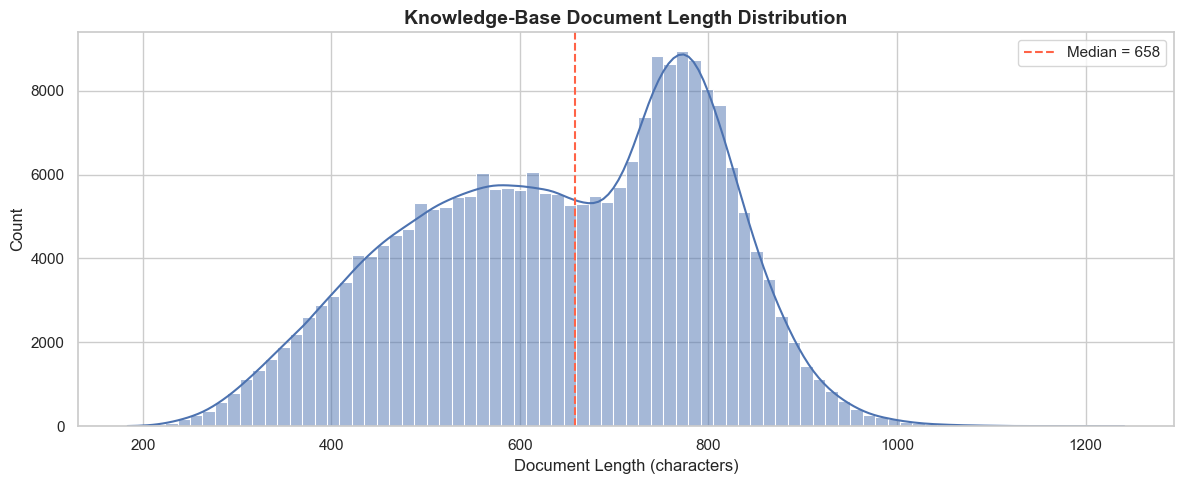

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 5))

doc_lengths = kb_df['document'].str.len()
sns.histplot(doc_lengths, bins=80, kde=True, color='#4c72b0', ax=ax)
ax.set_title('Knowledge-Base Document Length Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Document Length (characters)')
ax.set_ylabel('Count')
ax.axvline(doc_lengths.median(), color='tomato', ls='--', label=f'Median = {doc_lengths.median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Save Knowledge Base

We save two formats:
1. **CSV** — for easy inspection and downstream Pandas usage.
2. **JSON-Lines** — one JSON object per line, ideal for streaming ingestion into a vector store.

In [10]:
# Select final columns
final_cols = [
    'id', 'name', 'ingredients_str', 'calories', 'protein_pdv',
    'total_fat_pdv', 'prep_time_mins', 'avg_rating', 'review_count',
    'review_summary', 'document'
]
kb_final = kb_df[final_cols].copy()
kb_final.rename(columns={'id': 'recipe_id'}, inplace=True)

# ── Save CSV ──
kb_final.to_csv(KB_CSV_PATH, index=False)
print(f'CSV saved  -> {KB_CSV_PATH}  ({KB_CSV_PATH.stat().st_size / 1e6:.1f} MB)')

# ── Save JSONL ──
with open(KB_JSONL_PATH, 'w', encoding='utf-8') as f:
    for _, row in kb_final.iterrows():
        record = row.to_dict()
        f.write(json.dumps(record, ensure_ascii=False) + '\n')

print(f'JSONL saved -> {KB_JSONL_PATH}  ({KB_JSONL_PATH.stat().st_size / 1e6:.1f} MB)')
print(f'\nTotal documents: {len(kb_final):,}')
print('\n[OK] Knowledge base saved successfully.')

CSV saved  -> dataset\archive_3\food_knowledge_base.csv  (288.5 MB)


JSONL saved -> dataset\archive_3\food_knowledge_base.jsonl  (330.7 MB)

Total documents: 231,637

[OK] Knowledge base saved successfully.


## 11. Summary

| Item | Value |
|------|-------|
| Total recipes in knowledge base | `len(kb_final)` |
| Fields per document | Name, Ingredients, Calories, Protein, Fat, Prep Time, Rating, Review Summary |
| Output formats | CSV + JSON-Lines |

**Next step ->** Use the knowledge base in **Notebook 13** to build a FAISS vector store with SentenceTransformer embeddings for semantic search & RAG.